# TP1 – PCA y Monte Carlo sobre PneumoniaMNIST

Inferencia y Estimación (I206), UdeSA. El dataset debe estar en `../dataset_tp1/` (`train/`, `test/`, `train_labels.csv`, `test_labels.csv`). Las figuras se guardan en `../figures/`.

## Ejercicio 1: PCA y accuracy en función de K

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Módulo para manejo de imágenes
import pandas as pd
from PIL import Image
from pathlib import Path

def process_image(img_path : str, rotate=False) -> np.ndarray:
    img = Image.open(img_path).convert("L")
    img_matrix = np.array(img)
    if rotate:
        return np.rot90(img_matrix, 2)
    return img_matrix

def read_images(folder : Path, csv : pd.DataFrame) -> np.ndarray:
    images = []
    tags = []
    for _, row in csv.iterrows():
        image_name = row["archivo"]
        tag = row["clase"]

        image_path = folder / image_name
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")  
        images.append(process_image(image_path))
        tags.append(tag)
    return np.array(images), np.array(tags) # Matrix con filas las realizaciones y Vector con las etiquetas asociadas

def flatten_images(images):
    return images.reshape(images.shape[0], -1)


In [3]:
# Entrenamiento y testeo de modelo
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

def train_classifier(lr_model : LogisticRegression, X : np.ndarray, y : np.ndarray) -> None:  
    lr_model.fit(X, y)
    return None
def test_classifier(lr_model : LogisticRegression, X : np.ndarray, y : np.ndarray) -> float: 
    y_pred = lr_model.predict(X)
    acc = accuracy_score(y, y_pred)
    return acc


In [4]:
# Principal Component Analysis via SVD
def fit_pca(X_train: np.ndarray):  
    mu = X_train.mean(axis=0)
    X_centered = X_train - mu
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    return U, S, Vt, mu

def proyectar_componentes(X: np.ndarray, Vt: np.ndarray, mu: np.ndarray, K: int) -> np.ndarray:  
    Vk = Vt[:K, :].T                    # matriz de proyección (d, K), obtenida de train
    return (X - mu) @ Vk                # centrado con la media de train (parte del 'entrenamiento' de PCA)
                                        # para train esto es idéntico a U_k @ diag(S_k) 


In [ ]:
# Inciso C
N = 20000
def K_PCA(X_train, y_train, X_test, y_test, Vt, mu, Kmin=1, Kmax=300):  
    Ks = []
    accuracies = []  

    for K in range(Kmin, Kmax+1):
        lr_model = LogisticRegression(max_iter=N)
        Xk_train = proyectar_componentes(X_train, Vt, mu, K)  
        Xk_test = proyectar_componentes(X_test, Vt, mu, K)

        train_classifier(lr_model, Xk_train, y_train)
        accuracy = test_classifier(lr_model, Xk_test, y_test)
        Ks.append(K)
        accuracies.append(accuracy)

    return np.array(Ks), np.array(accuracies)

In [6]:
FIG_DIR = Path("../figures")  
FIG_DIR.mkdir(exist_ok=True)

training_folder = Path("../dataset_tp1/train")
df_train = pd.read_csv("../dataset_tp1/train_labels.csv")
X_train, y_train = read_images(training_folder, df_train)
X_train = flatten_images(X_train)

testing_folder = Path("../dataset_tp1/test")
df_test = pd.read_csv("../dataset_tp1/test_labels.csv")
X_test, y_test = read_images(testing_folder, df_test)
X_test = flatten_images(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (2428, 16384)  Test: (468, 16384)


In [7]:
# Inciso A: LR con las imágenes completas (sin PCA)
lr_model = LogisticRegression(max_iter=N)
train_classifier(lr_model, X_train, y_train)
accuracy_full = test_classifier(lr_model, X_test, y_test)
print("Accuracy reported: ", accuracy_full)


Accuracy reported:  0.8183760683760684


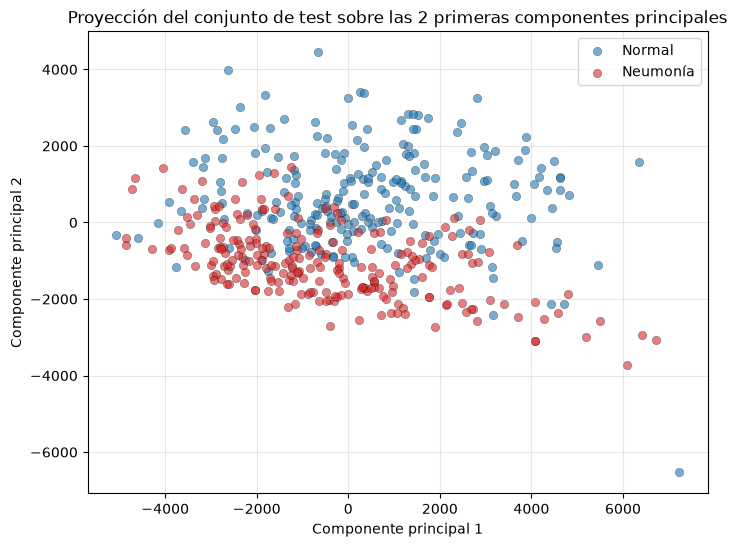

In [8]:
# Inciso B: proyección de test sobre las 2 primeras componentes principales
U, S, Vt, mu = fit_pca(X_train)  
X_test_proj = proyectar_componentes(X_test, Vt, mu, K=2)

# Scatter diferenciando clases por color
plt.figure(figsize=(8, 6))
colores = {0: "tab:blue", 1: "tab:red"}
etiquetas = {0: "Normal", 1: "Neumonía"}

for clase in [0, 1]:
    mask = y_test == clase
    plt.scatter(
        X_test_proj[mask, 0],
        X_test_proj[mask, 1],
        c=colores[clase],
        label=etiquetas[clase],
        alpha=0.6,
        edgecolors="k",
        linewidths=0.3,
    )

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Proyección del conjunto de test sobre las 2 primeras componentes principales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "pca_scatter.png", dpi=150, bbox_inches="tight")  
plt.show()


/Users/bautista/Documents/Udesa/inferencia/TP1/pca-montecarlo-pneumonia/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 13886 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/bautista/Documents/Udesa/inferencia/TP1/pca-montecarlo-pneumonia/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 13833 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/bautista/Documents/Udesa/inferencia/TP1/pca-montecarlo-pneumonia/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 13861 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/bautista/Documents/Udesa/inferencia/TP1/pca-montecarlo-pneumonia/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 13839 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/bautista/Documents/Udesa/inferencia/TP1/pca-montecarlo-pneumonia/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 13845 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/bautista/Documents/Udesa/inferencia/TP1/pca-montecarlo-pneumonia/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 13885 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/bautista/Documents/Udesa/inferencia/TP1/pca-montecarlo-pneumonia/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 13815 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


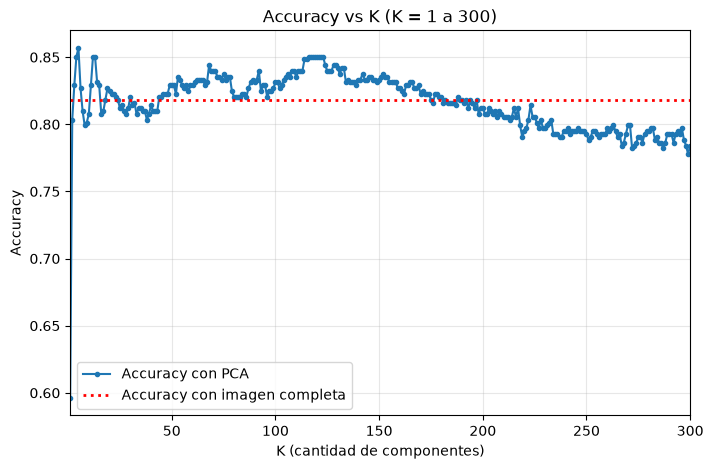

Accuracy sin PCA: 0.8184
Mejor accuracy con PCA: 0.8568 (K = 5)
Primer K que alcanza el accuracy sin PCA: K = 3


In [9]:
# Inciso C: accuracy vs K
Ks, accuracies = K_PCA(X_train, y_train, X_test, y_test, Vt, mu)  # reutiliza la PCA ajustada en el inciso B

plt.figure(figsize=(8, 5))
# Puntos (K, accuracy)
plt.plot(Ks, accuracies, marker="o", markersize=3, linestyle="-", label="Accuracy con PCA")

# Línea punteada con el accuracy de la imagen completa (inciso a)
plt.axhline(y=accuracy_full, color="red", linestyle=":", linewidth=2, label="Accuracy con imagen completa")  

plt.xlabel("K (cantidad de componentes)")
plt.xlim(Ks.min(), Ks.max())
plt.ylabel("Accuracy")
plt.title(f"Accuracy vs K (K = {Ks.min()} a {Ks.max()})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIG_DIR / "accuracy_vs_k.png", dpi=150, bbox_inches="tight")  
plt.show()

print(f"Accuracy sin PCA: {accuracy_full:.4f}")
print(f"Mejor accuracy con PCA: {accuracies.max():.4f} (K = {Ks[accuracies.argmax()]})")
print(f"Primer K que alcanza el accuracy sin PCA: K = {Ks[np.argmax(accuracies >= accuracy_full)]}")


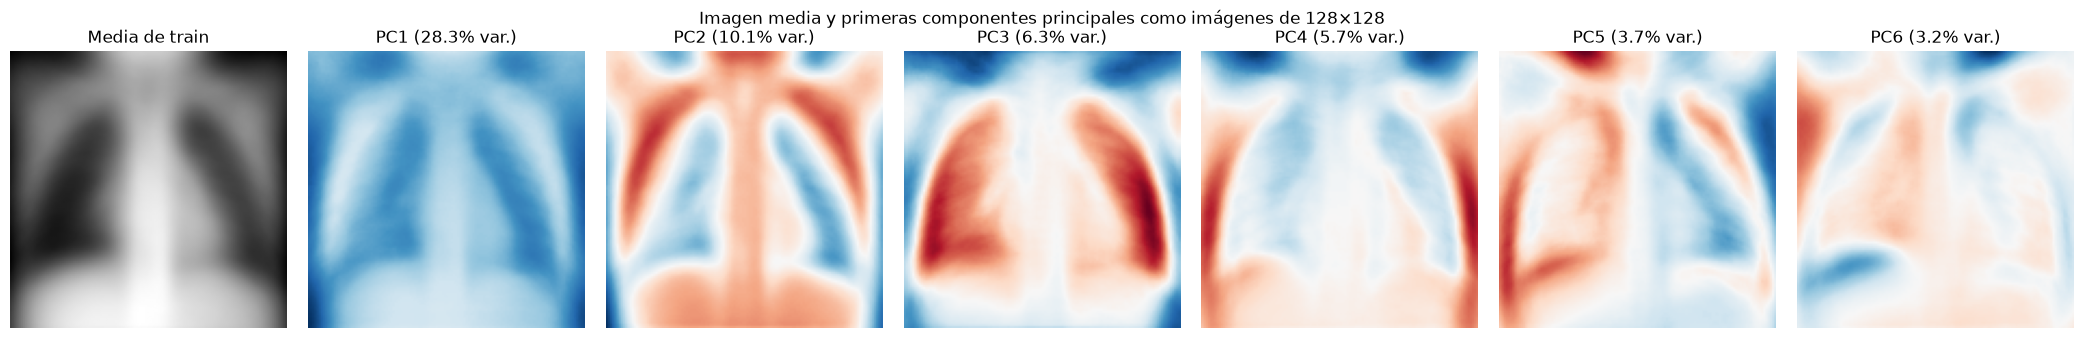

In [10]:
# Extra: imagen media y primeras componentes principales vistas como imágenes
# Cada fila de Vt es una dirección principal con un valor por píxel (16384 = 128*128),
# así que se puede reacomodar como imagen y ver "a qué zonas del tórax mira" cada componente.
lado = int(np.sqrt(X_train.shape[1]))   # 128
n_comp = 6                              # cantidad de componentes a mostrar

fig, axes = plt.subplots(1, n_comp + 1, figsize=(3 * (n_comp + 1), 3.4))

# Imagen media de train: es lo que se resta a cada imagen antes de proyectar
axes[0].imshow(mu.reshape(lado, lado), cmap="gray")
axes[0].set_title("Media de train")

# Componentes principales: colormap divergente centrado en 0 para distinguir
# píxeles con peso positivo (rojo) y negativo (azul). El signo global de cada
# componente es arbitrario (la SVD puede devolver v o -v); importa el contraste entre zonas.
for j in range(n_comp):
    pc = Vt[j].reshape(lado, lado)
    lim = np.abs(pc).max()
    axes[j + 1].imshow(pc, cmap="RdBu_r", vmin=-lim, vmax=lim)
    var_j = S[j] ** 2 / np.sum(S ** 2)   # fracción de la varianza total que captura la componente
    axes[j + 1].set_title(f"PC{j + 1} ({100 * var_j:.1f}% var.)")

for ax in axes:
    ax.axis("off")

plt.suptitle("Imagen media y primeras componentes principales como imágenes de 128×128")
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_componentes_imagenes.png", dpi=150, bbox_inches="tight")
plt.show()



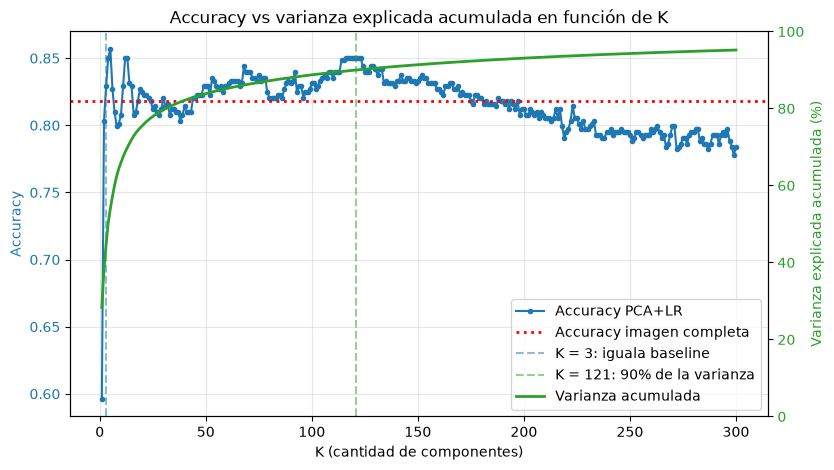

K =   1: varianza acumulada =  28.3%   accuracy = 0.596
K =   2: varianza acumulada =  38.4%   accuracy = 0.803
K =   3: varianza acumulada =  44.7%   accuracy = 0.829
K =   5: varianza acumulada =  54.0%   accuracy = 0.857
K =  10: varianza acumulada =  66.0%   accuracy = 0.808
K =  20: varianza acumulada =  75.5%   accuracy = 0.825
K =  50: varianza acumulada =  83.9%   accuracy = 0.829
K = 100: varianza acumulada =  88.7%   accuracy = 0.831
K = 200: varianza acumulada =  93.1%   accuracy = 0.812
K = 300: varianza acumulada =  95.2%   accuracy = 0.784
Para retener el 90% de la varianza hacen falta 121 componentes; el accuracy iguala al baseline con K = 3


In [11]:
# Extra: varianza explicada acumulada vs accuracy, en función de K
# Cada valor singular al cuadrado es la varianza que captura esa componente.
# Sumando las primeras K y dividiendo por el total se obtiene qué fracción de la
# variabilidad de train se conserva al proyectar a K dimensiones.
var_explicada = S ** 2 / np.sum(S ** 2)
var_acumulada = np.cumsum(var_explicada)

# K necesario para retener el 90% de la varianza (criterio clásico para elegir K en PCA)
K_90 = np.argmax(var_acumulada >= 0.90) + 1
# Primer K con el que PCA+LR iguala al accuracy de la imagen completa (reutiliza Ks y accuracies del inciso c)
K_baseline = Ks[np.argmax(accuracies >= accuracy_full)]

fig, ax_acc = plt.subplots(figsize=(9, 5))

# Eje izquierdo: accuracy (misma curva del inciso c)
ax_acc.plot(Ks, accuracies, marker="o", markersize=3, color="tab:blue", label="Accuracy PCA+LR")
ax_acc.axhline(accuracy_full, color="red", linestyle=":", linewidth=2, label="Accuracy imagen completa")
ax_acc.set_xlabel("K (cantidad de componentes)")
ax_acc.set_ylabel("Accuracy", color="tab:blue")
ax_acc.tick_params(axis="y", labelcolor="tab:blue")

# Eje derecho: varianza acumulada. Se extiende más allá del Kmax del inciso (c) para que llegue al 90%
K_var = np.arange(1, max(Ks.max(), K_90) + 1)
ax_var = ax_acc.twinx()
ax_var.plot(K_var, 100 * var_acumulada[K_var - 1], color="tab:green", linewidth=2, label="Varianza acumulada")
ax_var.set_ylabel("Varianza explicada acumulada (%)", color="tab:green")
ax_var.tick_params(axis="y", labelcolor="tab:green")
ax_var.set_ylim(0, 100)

# Líneas verticales: dónde satura el accuracy y dónde se llega al 90% de varianza
ax_acc.axvline(K_baseline, color="tab:blue", linestyle="--", alpha=0.5, label=f"K = {K_baseline}: iguala baseline")
ax_acc.axvline(K_90, color="tab:green", linestyle="--", alpha=0.5, label=f"K = {K_90}: 90% de la varianza")

# Leyenda combinada de los dos ejes
h1, l1 = ax_acc.get_legend_handles_labels()
h2, l2 = ax_var.get_legend_handles_labels()
ax_acc.legend(h1 + h2, l1 + l2, loc="lower right")
ax_acc.grid(True, alpha=0.3)
plt.title("Accuracy vs varianza explicada acumulada en función de K")
plt.savefig(FIG_DIR / "accuracy_vs_varianza.png", dpi=150, bbox_inches="tight")
plt.show()

for K in [1, 2, 3, 5, 10, 20, 50, 100, 200, 300]:
    print(f"K = {K:3d}: varianza acumulada = {100 * var_acumulada[K - 1]:5.1f}%   accuracy = {accuracies[K - 1]:.3f}")
print(f"Para retener el 90% de la varianza hacen falta {K_90} componentes; el accuracy iguala al baseline con K = {K_baseline}")


In [12]:
# Anexo: poder discriminante de cada componente por separado
# Para cada una de las primeras componentes se calcula:
#  - % de píxeles con el mismo signo que el peso dominante (100% => la componente mide brillo total)
#  - cociente de Fisher entre clases: (media_normal - media_neumonía)^2 / (var_normal + var_neumonía),
#    calculado sobre train; cuanto mayor, mejor separa las clases esa coordenada sola
#  - accuracy en test de una LR entrenada con esa única coordenada
n_comp = 6
Z_train = proyectar_componentes(X_train, Vt, mu, n_comp)
Z_test = proyectar_componentes(X_test, Vt, mu, n_comp)

print(f"{'PC':<4}{'% var.':>8}{'% mismo signo':>15}{'Fisher':>9}{'acc. 1 comp.':>14}")
for j in range(n_comp):
    var_j = S[j] ** 2 / np.sum(S ** 2)
    v = Vt[j]
    mismo_signo = np.mean(np.sign(v) == np.sign(v[np.abs(v).argmax()]))
    z0, z1 = Z_train[y_train == 0, j], Z_train[y_train == 1, j]
    fisher = (z0.mean() - z1.mean()) ** 2 / (z0.var() + z1.var())
    lr_1d = LogisticRegression(max_iter=N)
    train_classifier(lr_1d, Z_train[:, [j]], y_train)
    acc_1d = test_classifier(lr_1d, Z_test[:, [j]], y_test)
    print(f"PC{j + 1:<2}{100 * var_j:8.1f}{100 * mismo_signo:15.1f}{fisher:9.3f}{acc_1d:14.3f}")

# Correlación entre la coordenada PC1 y el brillo medio de cada imagen de train
brillo_medio = X_train.mean(axis=1)
print(f"\nCorrelación entre PC1 y brillo medio de la imagen: {np.corrcoef(Z_train[:, 0], brillo_medio)[0, 1]:.3f}")


PC    % var.  % mismo signo   Fisher  acc. 1 comp.
PC1     28.3          100.0    0.232         0.596
PC2     10.1           35.7    1.477         0.784
PC3      6.3           57.0    0.067         0.583
PC4      5.7           53.9    0.074         0.592
PC5      3.7           50.0    0.031         0.491
PC6      3.2           44.7    0.063         0.436

Correlación entre PC1 y brillo medio de la imagen: -0.982


## Ejercicio 2: Monte Carlo con rotaciones aleatorias

In [13]:
# Ejercicio 2: se recargan las imágenes normalizadas a [0, 1] (X_train, X_test se redefinen)
PATH = "../dataset_tp1/"

def load_set(name):
    labels = pd.read_csv(PATH + f"{name}_labels.csv")
    imgs = []
    for file in labels["archivo"]:
        img = Image.open(PATH + f"{name}/{file}").convert("L")
        vector = np.array(img, dtype=float).ravel() / 255 #Normalizamos los valores entre 0 y 1 (mejora la convergencia)
        imgs.append(vector)
    X = np.stack(imgs)
    y = labels["clase"].values
    return X, y

In [14]:
X_train, y_train = load_set("train")
mu_train = X_train.mean(axis=0)
centered_x = X_train - mu_train
U, S, V_t = np.linalg.svd(centered_x, full_matrices=False)
V = np.transpose(V_t)
V2 = V[:, :2]

In [15]:
def project(X):
    return (X - mu_train) @ V2

In [16]:
Y_train = project(X_train)
X_test, y_test = load_set("test")
Y_test = project(X_test)

model = LogisticRegression(max_iter=2000)

model.fit(Y_train, y_train)
y_pred = model.predict(Y_test)
A0 = accuracy_score(y_test, y_pred)
print(A0)

0.8034188034188035


In [17]:
def rotate_image(x):
    img_matrix = x.reshape(128, 128)
    rotated_x = np.rot90(img_matrix, 2)
    return rotated_x.ravel()

In [18]:
rng = np.random.default_rng(seed=0)
n_test = X_test.shape[0]

def raffle(n, p):
    # n uniformes U(0,1) independientes; U < p es una Bernoulli(p)
    return rng.random(n) < p

In [19]:
def perturb_images(imgs_mtx, mask):
    # Rota 180° las filas donde mask es True; no modifica imgs_mtx
    perturbed = imgs_mtx.copy()
    for i in np.where(mask)[0]:
        perturbed[i] = rotate_image(imgs_mtx[i])
    return perturbed

### Simulación Monte Carlo

Cada imagen de test solo puede estar derecha o rotada, así que se predice una vez en cada estado y en cada realización se elige según el sorteo. La celda siguiente verifica que coincide con rotar, proyectar y predecir.

In [20]:
X_test_rot = perturb_images(X_test, np.ones(n_test, dtype=bool))  # todo el test rotado
pred_orig = model.predict(project(X_test))
pred_rot = model.predict(project(X_test_rot))

def realization_accuracy(p):
    mask = raffle(n_test, p)
    pred = np.where(mask, pred_rot, pred_orig)
    return np.mean(pred == y_test)

def monte_carlo(p, n_mc):
    return np.array([realization_accuracy(p) for _ in range(n_mc)])

In [21]:
# Verificación: el método directo y el precalculado coinciden para las mismas máscaras
for p_check in [0.1, 0.5, 0.9]:
    mask = raffle(n_test, p_check)
    pred_direct = model.predict(project(perturb_images(X_test, mask)))
    pred_fast = np.where(mask, pred_rot, pred_orig)
    print(f"p = {p_check}: predicciones idénticas -> {np.array_equal(pred_direct, pred_fast)}")

p = 0.1: predicciones idénticas -> True
p = 0.5: predicciones idénticas -> True
p = 0.9: predicciones idénticas -> True


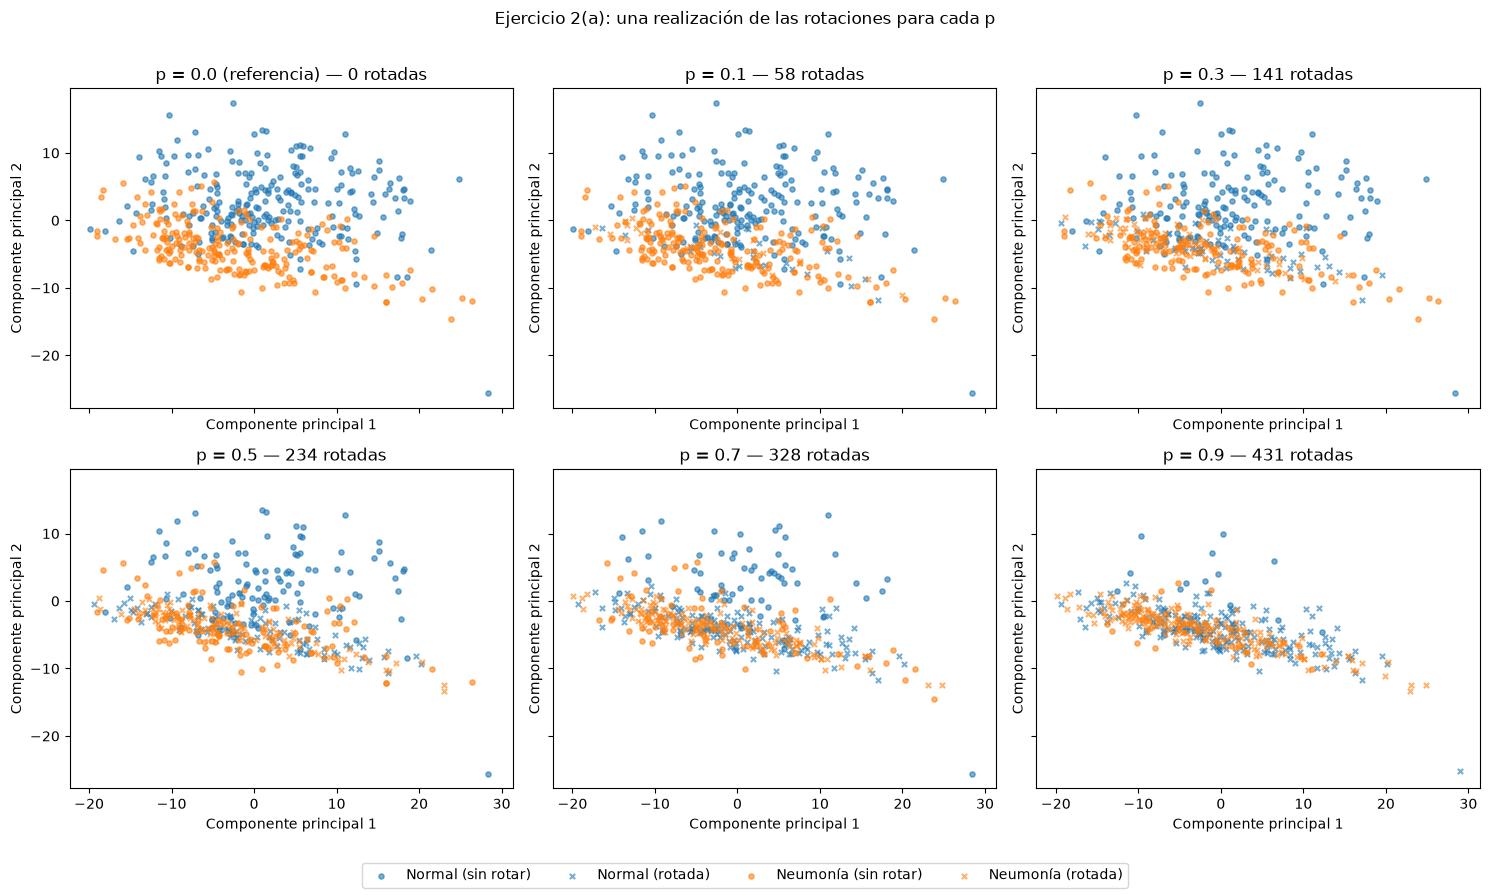

In [22]:
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]   # para scatters e histogramas
p_scatter = [0.0] + p_values            # p = 0 se usa solo como referencia (test sin rotar)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
for ax, p_case in zip(axes.flat, p_scatter):
    mask = raffle(n_test, p_case)
    Y_case = project(perturb_images(X_test, mask))
    for clase, nombre, color in [(0, "Normal", "tab:blue"), (1, "Neumonía", "tab:orange")]:
        for rotada, marcador, texto in [(False, "o", "sin rotar"), (True, "x", "rotada")]:
            filas = (y_test == clase) & (mask == rotada)
            ax.scatter(Y_case[filas, 0], Y_case[filas, 1], s=14, alpha=0.6,
                       color=color, marker=marcador, label=f"{nombre} ({texto})")
    titulo = f"p = {p_case:.1f}" + (" (referencia)" if p_case == 0 else "") + f" — {mask.sum()} rotadas"
    ax.set_title(titulo)
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")

handles, labels = axes.flat[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4)
fig.suptitle("Ejercicio 2(a): una realización de las rotaciones para cada p")
fig.tight_layout(rect=(0, 0.05, 1, 0.97))
fig.savefig(FIG_DIR / "perturbed_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

### Imágenes rotadas en el espacio PCA

Como $R(x) - \mu = R(x - \mu) + (R(\mu) - \mu)$, todas las rotadas comparten el desplazamiento $(R(\mu) - \mu)V_2$.

In [23]:
# Imágenes rotadas en el espacio PCA y efecto sobre el clasificador (no hace sorteos)
Y_orig = project(X_test)
Y_rot = project(X_test_rot)

desplazamiento = (rotate_image(mu_train) - mu_train) @ V2
print(f"Desplazamiento común (R(mu) - mu) proyectado: ({desplazamiento[0]:.2f}, {desplazamiento[1]:.2f})")
print(f"Desvío de la PC2: sin rotar = {Y_orig[:, 1].std():.2f}, rotadas = {Y_rot[:, 1].std():.2f}")
for clase, nombre in [(0, "Normal"), (1, "Neumonía")]:
    m = y_test == clase
    print(f"Media de la PC2 ({nombre}): sin rotar = {Y_orig[m, 1].mean():.2f}, rotadas = {Y_rot[m, 1].mean():.2f}")
print(f"Correlación de la PC1 antes y después de rotar: {np.corrcoef(Y_orig[:, 0], Y_rot[:, 0])[0, 1]:.3f}")

A1 = np.mean(pred_rot == y_test)   # accuracy con todo el test rotado
print(f"\nAccuracy sin rotar A0 = {A0:.3f}, con todo el test rotado A1 = {A1:.3f}")
print(f"Predichas como neumonía: sin rotar = {100 * np.mean(pred_orig == 1):.1f}%, rotadas = {100 * np.mean(pred_rot == 1):.1f}%")
for clase, nombre in [(0, "Normal"), (1, "Neumonía")]:
    m = y_test == clase
    print(f"Acierto en {nombre}: sin rotar = {np.mean(pred_orig[m] == clase):.3f}, rotadas = {np.mean(pred_rot[m] == clase):.3f}")
ok_orig, ok_rot = pred_orig == y_test, pred_rot == y_test
print(f"Imágenes cuya clasificación cambia al rotar: {np.sum(ok_orig != ok_rot)} "
      f"({np.sum(ok_orig & ~ok_rot)} de acierto a error, {np.sum(~ok_orig & ok_rot)} de error a acierto)")

Desplazamiento común (R(mu) - mu) proyectado: (-1.67, -3.87)
Desvío de la PC2: sin rotar = 5.55, rotadas = 2.83
Media de la PC2 (Normal): sin rotar = 2.58, rotadas = -4.32
Media de la PC2 (Neumonía): sin rotar = -4.07, rotadas = -4.17
Correlación de la PC1 antes y después de rotar: 0.987

Accuracy sin rotar A0 = 0.803, con todo el test rotado A1 = 0.521
Predichas como neumonía: sin rotar = 57.3%, rotadas = 97.4%
Acierto en Normal: sin rotar = 0.731, rotadas = 0.047
Acierto en Neumonía: sin rotar = 0.876, rotadas = 0.996
Imágenes cuya clasificación cambia al rotar: 188 (160 de acierto a error, 28 de error a acierto)


In [24]:
N_MC = 2000
eps = 0.05
# Cota de Chebyshev para el estimador de una probabilidad: Var <= 1/(4 N_MC)
print(f"Desvío máximo del estimador de probabilidad: {np.sqrt(1 / (4 * N_MC)):.4f}")
print(f"Cota P(|error| >= {eps}) <= {1 / (4 * N_MC * eps**2):.3f}")

p_fine = [round(float(p), 2) for p in np.arange(0.05, 0.91, 0.05)]  # grilla fina para (b) y (c)
acc_by_p = {p_case: monte_carlo(p_case, N_MC) for p_case in p_fine}

Desvío máximo del estimador de probabilidad: 0.0112
Cota P(|error| >= 0.05) <= 0.050


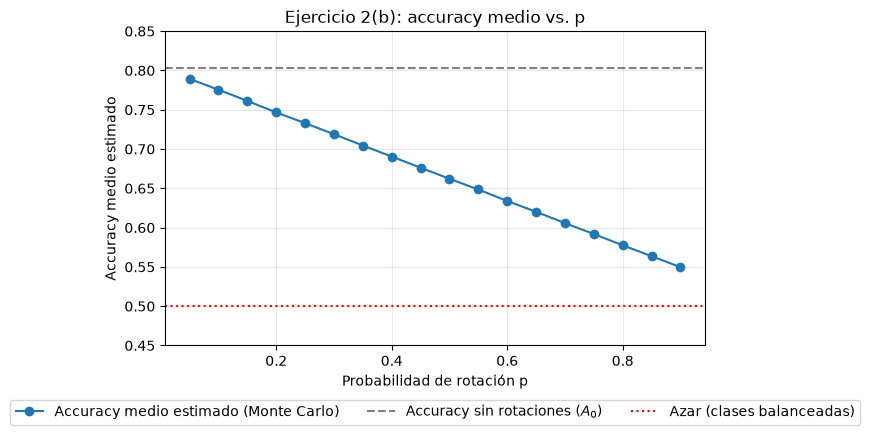

In [25]:
mean_accuracy = [acc_by_p[p_case].mean() for p_case in p_fine]

plt.figure(figsize=(8, 4.5))
plt.plot(p_fine, mean_accuracy, marker="o", label="Accuracy medio estimado (Monte Carlo)")
plt.axhline(A0, color="gray", linestyle="--", label="Accuracy sin rotaciones ($A_0$)")
plt.axhline(0.5, color="red", linestyle=":", label="Azar (clases balanceadas)")
plt.xlabel("Probabilidad de rotación p")
plt.ylabel("Accuracy medio estimado")
plt.title("Ejercicio 2(b): accuracy medio vs. p")
plt.ylim(0.45, 0.85)
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.tight_layout()
plt.savefig(FIG_DIR / "expected_accuracy_vs_p.png", dpi=150, bbox_inches="tight")
plt.show()

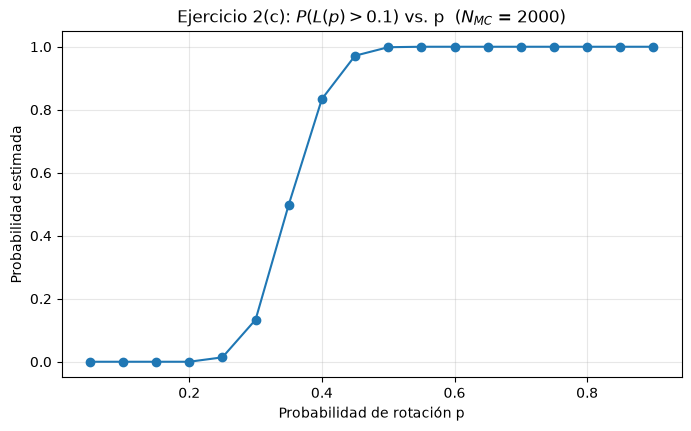

In [26]:
delta = 0.1
prob_loss = [np.mean((A0 - acc_by_p[p_case]) > delta) for p_case in p_fine]

plt.figure(figsize=(8, 4.5))
plt.plot(p_fine, prob_loss, marker="o")
plt.xlabel("Probabilidad de rotación p")
plt.ylabel("Probabilidad estimada")
plt.title(rf"Ejercicio 2(c): $P(L(p) > {delta})$ vs. p  ($N_{{MC}}$ = {N_MC})")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.savefig(FIG_DIR / "loss_probability_vs_p.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# Valores numéricos de (b) y (c), comparados con E[A_p] = (1 - p) A0 + p A1 (no hace sorteos)
# Desvío teórico: solo influyen las imágenes cuya clasificación cambia al rotar -> Var(A_p) = m p (1 - p) / n^2
m_cambian = np.sum((pred_orig == y_test) != (pred_rot == y_test))
print(f"{'p':>5}{'E[A_p] MC':>11}{'(1-p)A0+pA1':>13}{'desvío':>9}{'desvío teórico':>16}{'P(L>0.1)':>10}")
dif_max = 0
for p_case in p_fine:
    acc = acc_by_p[p_case]
    recta = (1 - p_case) * A0 + p_case * A1
    desvio_teo = np.sqrt(m_cambian * p_case * (1 - p_case)) / n_test
    dif_max = max(dif_max, abs(acc.mean() - recta))
    print(f"{p_case:5.2f}{acc.mean():11.4f}{recta:13.4f}{acc.std():9.4f}{desvio_teo:16.4f}{np.mean(A0 - acc > delta):10.4f}")

print(f"\nMáxima diferencia entre Monte Carlo y la recta: {dif_max:.4f}")
print(f"L(p) > {delta} equivale a tener como máximo {int(np.ceil((A0 - delta) * n_test)) - 1} aciertos (sin rotar: {round(A0 * n_test)})")
print(f"p* = delta / (A0 - A1) = {delta / (A0 - A1):.3f}")

    p  E[A_p] MC  (1-p)A0+pA1   desvío  desvío teórico  P(L>0.1)
 0.05     0.7893       0.7893   0.0062          0.0064    0.0000
 0.10     0.7755       0.7752   0.0088          0.0088    0.0000
 0.15     0.7612       0.7611   0.0102          0.0105    0.0000
 0.20     0.7466       0.7470   0.0118          0.0117    0.0000
 0.25     0.7330       0.7329   0.0129          0.0127    0.0140
 0.30     0.7188       0.7188   0.0133          0.0134    0.1335
 0.35     0.7045       0.7047   0.0144          0.0140    0.4985
 0.40     0.6904       0.6906   0.0145          0.0144    0.8340
 0.45     0.6763       0.6765   0.0145          0.0146    0.9715
 0.50     0.6621       0.6624   0.0150          0.0146    0.9985
 0.55     0.6485       0.6483   0.0145          0.0146    1.0000
 0.60     0.6338       0.6342   0.0142          0.0144    1.0000
 0.65     0.6201       0.6201   0.0140          0.0140    1.0000
 0.70     0.6057       0.6060   0.0134          0.0134    1.0000
 0.75     0.5919       0.

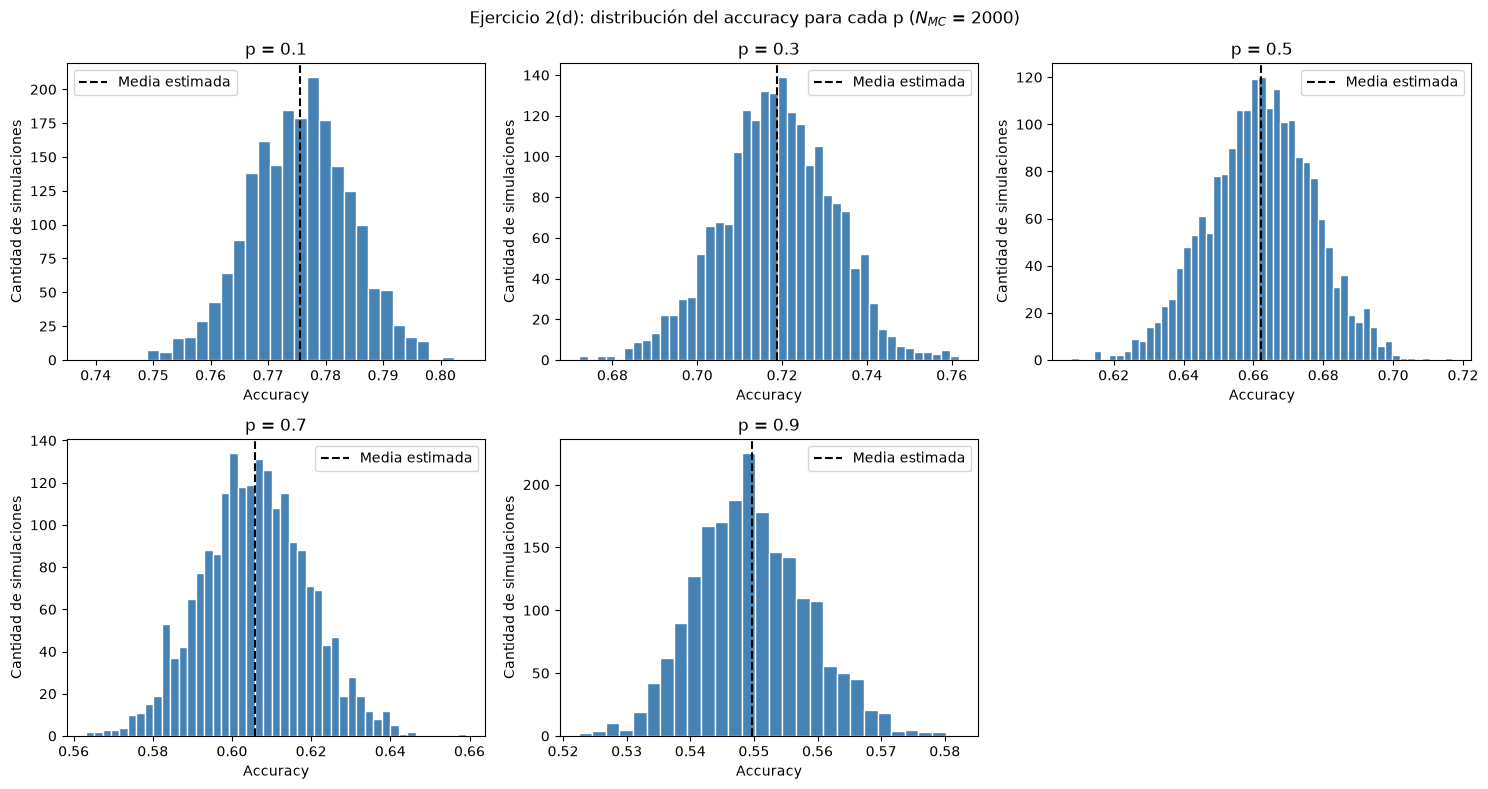

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, p_case in zip(axes.flat, p_values):
    acc = acc_by_p[p_case]
    # El accuracy solo toma valores k/n_test: un intervalo centrado en cada valor posible
    k_min = round(acc.min() * n_test)
    k_max = round(acc.max() * n_test)
    bins = (np.arange(k_min, k_max + 2) - 0.5) / n_test
    ax.hist(acc, bins=bins, color="steelblue", edgecolor="white")
    ax.axvline(acc.mean(), color="black", linestyle="--", label="Media estimada")
    ax.set_title(f"p = {p_case:.1f}")
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Cantidad de simulaciones")
    ax.legend()
axes.flat[-1].axis("off")
fig.suptitle(f"Ejercicio 2(d): distribución del accuracy para cada p ($N_{{MC}}$ = {N_MC})")
fig.tight_layout()
fig.savefig(FIG_DIR / "accuracy_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

### Estabilidad de las estimaciones Monte Carlo (p = 0.35)

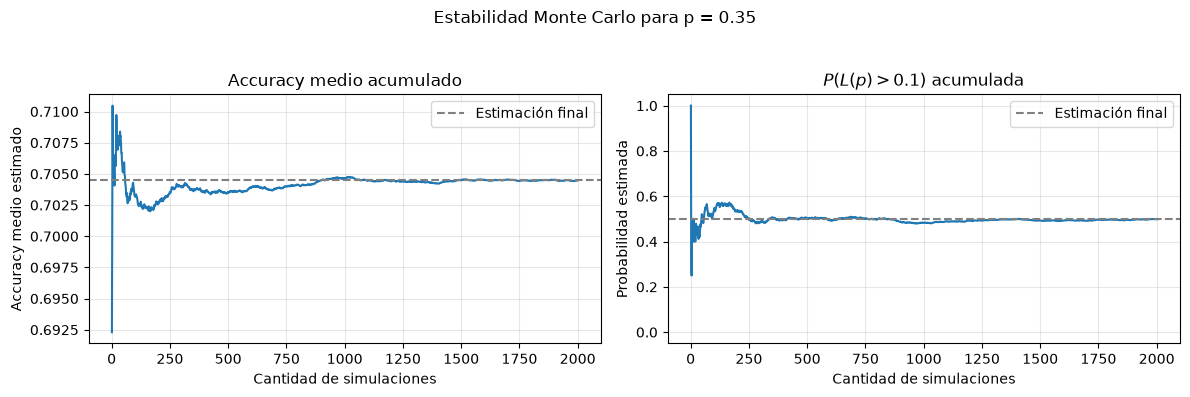

In [29]:
p_extra = 0.35
acc_extra = np.asarray(acc_by_p[p_extra])
trials = np.arange(1, len(acc_extra) + 1)
running_acc = np.cumsum(acc_extra) / trials
loss_events = (A0 - acc_extra > delta).astype(int)
running_prob = np.cumsum(loss_events) / trials

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(trials, running_acc)
axes[0].axhline(acc_extra.mean(), color="gray", linestyle="--", label="Estimación final")
axes[0].set_xlabel("Cantidad de simulaciones")
axes[0].set_ylabel("Accuracy medio estimado")
axes[0].set_title("Accuracy medio acumulado")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(trials, running_prob)
axes[1].axhline(loss_events.mean(), color="gray", linestyle="--", label="Estimación final")
axes[1].set_xlabel("Cantidad de simulaciones")
axes[1].set_ylabel("Probabilidad estimada")
axes[1].set_title(r"$P(L(p) > 0.1)$ acumulada")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_yticks(np.linspace(0, 1, 6))
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"Estabilidad Monte Carlo para p = {p_extra}")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIG_DIR / "monte_carlo_convergence.png", dpi=150, bbox_inches="tight")
plt.show()